develop a predictive model for predicting house prices using random forest

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [2]:
house_data = fetch_california_housing()


In [3]:
print(house_data.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [4]:
print(house_data.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [5]:
print(house_data.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [6]:
print(house_data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
import pandas as pd
df = pd.DataFrame(house_data.data, columns = house_data.feature_names)
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
                                    house_data.data ,
                                    house_data.target,
                                    test_size=0.2,
                                    random_state=42
)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

In [10]:
model = RandomForestRegressor(n_estimators = 100,
                              criterion = 'squared_error',
                              verbose = 1
                              )

In [11]:
model = model.fit(X_train,y_train)
y_pred = model.predict(X_test)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.4s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    9.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [12]:
from sklearn.metrics import r2_score

In [13]:
print(f"R^2 Score : {r2_score(y_test, y_pred)}")

R^2 Score : 0.8071048544050154


Random Forest Classifiers

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
#y = (house_data.target > house_data.target.mean()).astype(int)
#print(y)


In [16]:
import numpy as np

In [17]:
m=house_data.target.mean()
y = np.where(house_data.target > m,1,0)

In [18]:
X_train, X_test, y_train, y_test = train_test_split( house_data.data,
                                                    y, test_size = 0.2,
                                                    random_state = 42)

In [19]:
model = RandomForestClassifier( n_estimators = 100, 
                               criterion = 'entropy')


In [20]:
model.fit( X_train, y_train )

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [ ]:
print( f"accuracy: {accuracy_score(y_test, y_pred)}" )

accuracy: 0.8941375968992248


In [24]:
print( f"classification Report : {classification_report(y_test, y_pred)}" )

classification Report :               precision    recall  f1-score   support

           0       0.90      0.93      0.91      2476
           1       0.89      0.84      0.86      1652

    accuracy                           0.89      4128
   macro avg       0.89      0.89      0.89      4128
weighted avg       0.89      0.89      0.89      4128



In [25]:
print( f"F1 Score : {f1_score(y_test, y_pred)}" )

F1 Score : 0.8644961240310077


In [26]:
print( f"confusion matrix : {confusion_matrix(y_test, y_pred)}" )

confusion matrix : [[2297  179]
 [ 258 1394]]


In [27]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'feature importance levels')

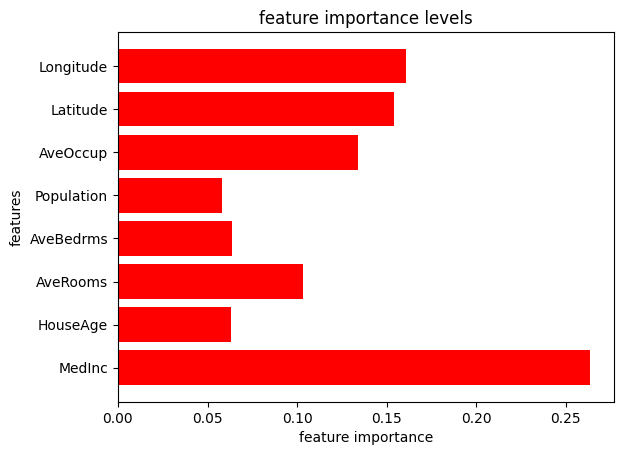

In [32]:

plt.barh(house_data.feature_names, model.feature_importances_, color='red')
plt.xlabel('feature importance')
plt.ylabel('features')
plt.title('feature importance levels')